**Sentiment Analysis**

In [ ]:
!pip install pandas matplotlib seaborn nltk wordcloud textblob


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


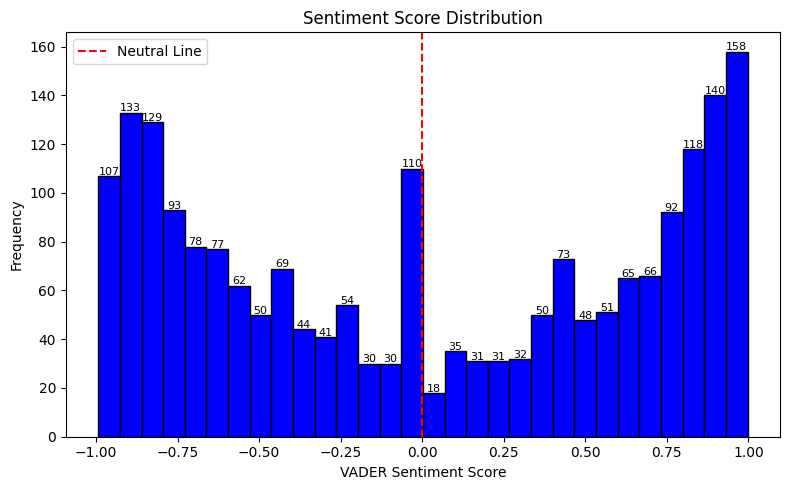

<ipython-input-4-eb3115c575ae>:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='rating', y='vader_score', data=rating_sentiment, palette="coolwarm")


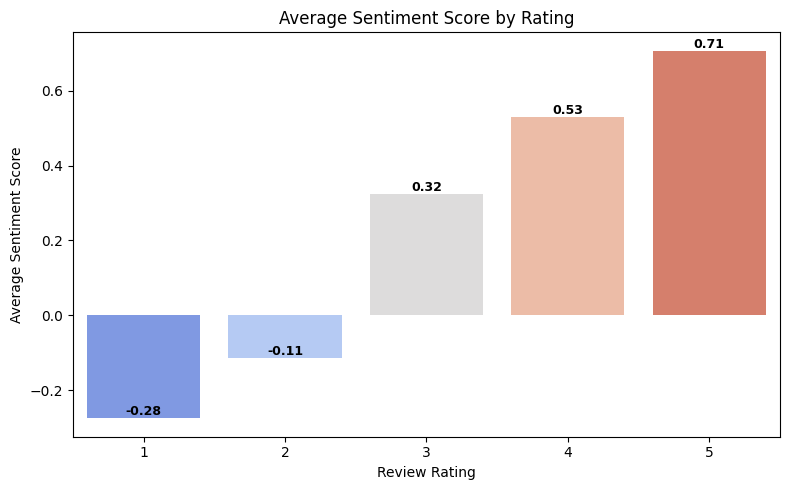

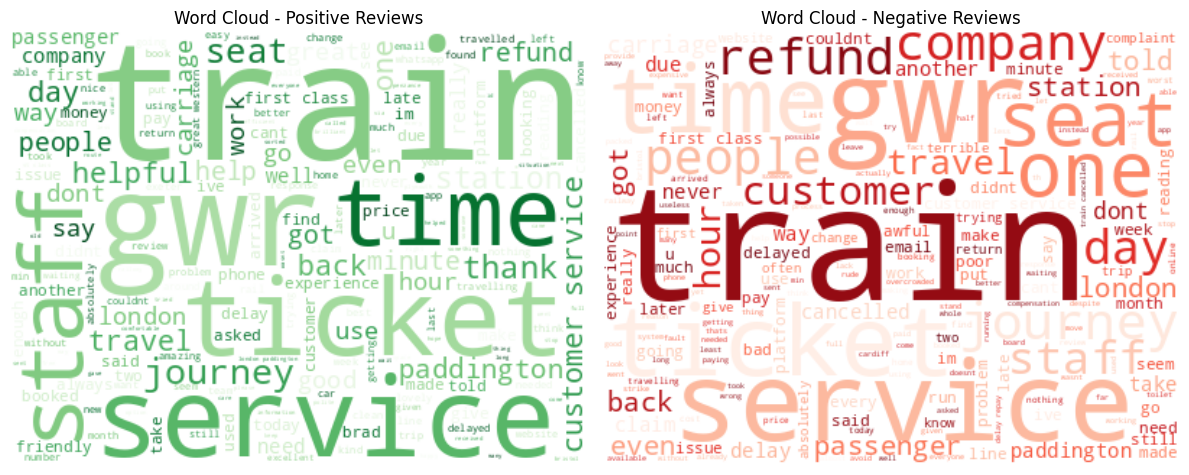

Sentiment Distribution:
sentiment
Negative    1008
Positive     997
Neutral      110
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from wordcloud import WordCloud
from textblob import TextBlob

# Download NLTK data
nltk.download('vader_lexicon')
nltk.download('stopwords')

# Initialize tools
sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words("english"))

# Text cleaning function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [word for word in text.split() if word not in stop_words]
    return " ".join(tokens)

# Load dataset
file_path = "/content/GWR with date.csv"
df = pd.read_csv(file_path)
df['content'] = df['content'].fillna('').astype(str)

# Preprocess and analyze sentiment
df['cleaned_content'] = df['content'].apply(preprocess_text)
df['vader_score'] = df['cleaned_content'].apply(lambda x: sia.polarity_scores(x)['compound'])
df['textblob_polarity'] = df['cleaned_content'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['sentiment'] = df['vader_score'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

# --- Visualization 1: Sentiment Score Distribution with Value Labels ---
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(df['vader_score'], bins=30, color='blue', edgecolor='black')
plt.axvline(0, color='red', linestyle='dashed', label='Neutral Line')
for i in range(len(patches)):
    height = counts[i]
    if height > 0:
        plt.text(patches[i].get_x() + patches[i].get_width()/2, height + 0.5,
                 f'{int(height)}', ha='center', fontsize=8)
plt.title("Sentiment Score Distribution")
plt.xlabel("VADER Sentiment Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# --- Visualization 2: Sentiment vs. Ratings with Labels ---
if 'rating' in df.columns:
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
    rating_sentiment = df.groupby('rating')['vader_score'].mean().reset_index()

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x='rating', y='vader_score', data=rating_sentiment, palette="coolwarm")

    # Add labels
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:.2f}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

    plt.title("Average Sentiment Score by Rating")
    plt.xlabel("Review Rating")
    plt.ylabel("Average Sentiment Score")
    plt.tight_layout()
    plt.show()

# --- Visualization 3: Word Clouds ---
positive_text = " ".join(df[df['sentiment'] == 'Positive']['cleaned_content'].dropna())
negative_text = " ".join(df[df['sentiment'] == 'Negative']['cleaned_content'].dropna())

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
wordcloud_pos = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")

plt.subplot(1, 2, 2)
wordcloud_neg = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.tight_layout()
plt.show()

# Print sentiment counts
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/GWR with date.csv")  # Replace with your actual file path

# Drop rows with missing ratings (optional but recommended)
df = df.dropna(subset=['rating'])

# Convert rating column to numeric (in case it's read as string)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Create sentiment column based on rating
df['sentiment'] = df['rating'].apply(lambda x: 'Positive' if x > 3 else 'Negative')

# Count positive and negative reviews
sentiment_counts = df['sentiment'].value_counts()

# Display results
print("Review Sentiment Counts:")
print(sentiment_counts)


Review Sentiment Counts:
sentiment
Negative    1538
Positive     577
Name: count, dtype: int64


**Web scraping with Date for seasonlaity Analysis**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re

def scrape_trustpilot_reviews(company_name, num_pages=1):
    """
    Scrape reviews from Trustpilot for a specific company, including Date of Experience.

    Args:
        company_name (str): The company name as it appears in Trustpilot URL
        num_pages (int): Number of pages to scrape

    Returns:
        DataFrame: A pandas DataFrame containing the scraped reviews
    """
    reviews_data = []

    # Define headers to mimic a real browser
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36',
        'Accept-Language': 'en-US,en;q=0.9',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Referer': 'https://www.google.com/'
    }

    for page in range(1, num_pages + 1):
        url = f"https://www.trustpilot.com/review/{company_name}?page={page}"
        print(f"Scraping page {page} of {num_pages}: {url}")

        try:
            response = requests.get(url, headers=headers)

            if response.status_code == 200:
                soup = BeautifulSoup(response.text, 'html.parser')

                # Debugging: Print a sample of HTML
                print(f"Response received. HTML sample: {response.text[:500]}...")

                # Find all review containers
                review_containers = soup.find_all('article', {'class': re.compile('paper_paper.*')}) or \
                                    soup.find_all('div', {'data-service-review-card-paper': True}) or \
                                    soup.find_all('div', {'class': re.compile('styles_cardWrapper.*')})

                print(f"Found {len(review_containers)} review containers")

                for container in review_containers:
                    try:
                        # Extract username
                        username_element = container.find('span', {'class': re.compile('typography_heading-.*')}) or \
                                          container.find('span', {'class': re.compile('styles_consumerName.*')}) or \
                                          container.find('div', {'class': re.compile('styles_consumerDetails.*')})
                        username = username_element.text.strip() if username_element else "Anonymous"

                        # Extract rating
                        rating = "N/A"
                        rating_div = container.find('div', {'data-service-review-rating': True})
                        if rating_div:
                            rating_value = rating_div.get('data-service-review-rating')
                            if rating_value:
                                rating = rating_value

                        # If rating not found, try to find it in the img alt text
                        if rating == "N/A":
                            rating_img = container.find('img', {'alt': re.compile('.*star.*')})
                            if rating_img and 'alt' in rating_img.attrs:
                                rating = rating_img['alt'].split()[0]

                        # Extract review title
                        title_element = container.find('h2', {'class': re.compile('styles_reviewTitle.*')}) or \
                                       container.find('h2', {'class': re.compile('typography_heading-.*')})
                        title = title_element.text.strip() if title_element else "No Title"

                        # Extract review content
                        content_element = container.find('p', {'class': re.compile('styles_reviewContent.*')}) or \
                                         container.find('p', {'class': re.compile('typography_body-.*')})
                        content = content_element.text.strip() if content_element else "No Content"

                        # Extract Date of Experience
                        date_experience_element = container.find('time', {'class': re.compile('typography_body-.*')}) or \
                                                  container.find('p', {'class': re.compile('styles_reviewDate.*')})
                        date_experience = date_experience_element.text.strip() if date_experience_element else "No Date"

                        # Debugging output
                        print(f"Extracted review - Username: {username}, Rating: {rating}, Date: {date_experience}, Title: {title[:20]}...")

                        # Append to list
                        reviews_data.append({
                            'username': username,
                            'rating': rating,
                            'title': title,
                            'content': content,
                            'date_of_experience': date_experience
                        })

                    except Exception as e:
                        print(f"Error extracting review data: {e}")

            else:
                print(f"Failed to fetch page {page}. Status code: {response.status_code}")

        except Exception as e:
            print(f"Error fetching page {page}: {e}")

        # Add a random delay to avoid being blocked
        if page < num_pages:
            delay = random.uniform(3, 7)
            print(f"Waiting for {delay:.2f} seconds before next request...")
            time.sleep(delay)

    # Convert the data to a DataFrame
    df = pd.DataFrame(reviews_data)
    return df

def save_to_csv(df, filename="trustpilot_reviews.csv"):
    """Save the DataFrame to a CSV file"""
    if df.empty:
        print("Warning: DataFrame is empty! No data to save.")
    else:
        df.to_csv(filename, index=False, encoding='utf-8')
        print(f"Data saved to {filename} with {len(df)} reviews.")

def main():
    print(f"Starting to scrape reviews for 'https://www.trustpilot.com/review/www.gwr.com'...")
    df = scrape_trustpilot_reviews("www.gwr.com", 106)

    if df.empty:
        print("No reviews were scraped. Check the HTML structure and try again.")
    else:
        print(f"Scraped {len(df)} reviews.")
        save_to_csv(df, "gwr_reviews.csv")

if __name__ == "__main__":
    main()


Starting to scrape reviews for 'https://www.trustpilot.com/review/www.gwr.com'...
Scraping page 1 of 106: https://www.trustpilot.com/review/www.gwr.com?page=1
Response received. HTML sample: <!DOCTYPE html><html lang="en-US"><head><meta charSet="UTF-8"/><meta name="viewport" content="width=device-width, initial-scale=1"/><link rel="shortcut icon" type="image/x-icon" href="https://cdn.trustpilot.net/brand-assets/4.3.0/favicons/favicon.ico"/><link rel="manifest" href="/manifest.json"/><meta name="application-name" content="Trustpilot"/><meta name="theme-color" content="#1c1c1c"/><link rel="apple-touch-icon" sizes="180x180" href="https://cdn.trustpilot.net/brand-assets/4.3.0/favicons/a...
Found 20 review containers
Extracted review - Username: Yuriy Bezgin, Rating: 1, Date: No Date, Title: Why would you cancel...
Extracted review - Username: RU, Rating: 1, Date: No Date, Title: GwR should not be al...
Extracted review - Username: EY, Rating: 1, Date: No Date, Title: Officious and bumptu..

In [ ]:
import pandas as pd

# Load the file (Change filename accordingly)
file_path = "/content/GWR with date.csv"  # Change to .xlsx if Excel file
df = pd.read_csv(file_path)  # Use pd.read_excel(file_path) for Excel

# Check if "date_of_experience" column exists
if "date_of_experience" in df.columns:
    # Count occurrences of "No Date"
    no_date_count = (df["date_of_experience"] == "No Date").sum()

    # Count null values
    null_count = df["date_of_experience"].isnull().sum()

    print(f"Total occurrences of 'No Date': {no_date_count}")
    print(f"Total null values in 'date_of_experience': {null_count}")
else:
    print("Column 'date_of_experience' not found in the dataset.")


Total occurrences of 'No Date': 1402
Total null values in 'date_of_experience': 0


<ipython-input-3-8c5b13356854>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_of_experience'] = pd.to_datetime(df['date_of_experience'], errors='coerce')



Sentiment Trend Table (Month-Year Wise):
 year month_year  sentiment_score
 2017    2017-05        -0.414240
 2019    2019-03         0.693300
 2019    2019-04        -0.358687
 2019    2019-05         0.451258
 2019    2019-06         0.197136
 2019    2019-07         0.052660
 2019    2019-08        -0.432736
 2019    2019-09        -0.046985
 2019    2019-10        -0.095668
 2019    2019-11        -0.041096
 2019    2019-12        -0.284933
 2020    2020-01        -0.224910
 2020    2020-02         0.476604
 2020    2020-03        -0.284288
 2020    2020-04        -0.003318
 2020    2020-05         0.298200
 2020    2020-06        -0.889400
 2020    2020-07         0.413849
 2020    2020-08         0.576806
 2020    2020-09         0.511067
 2020    2020-10         0.571695
 2020    2020-11         0.511540
 2021    2021-02         0.139400
 2021    2021-03         0.432158
 2021    2021-04         0.789860
 2021    2021-11         0.039146
 2021    2021-12        -0.248856
 2022 

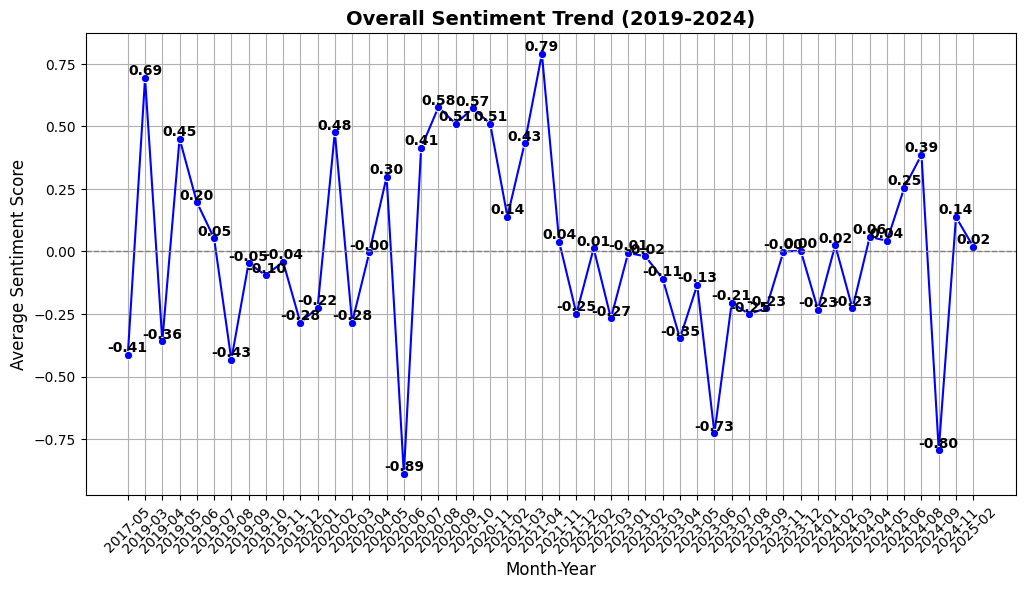

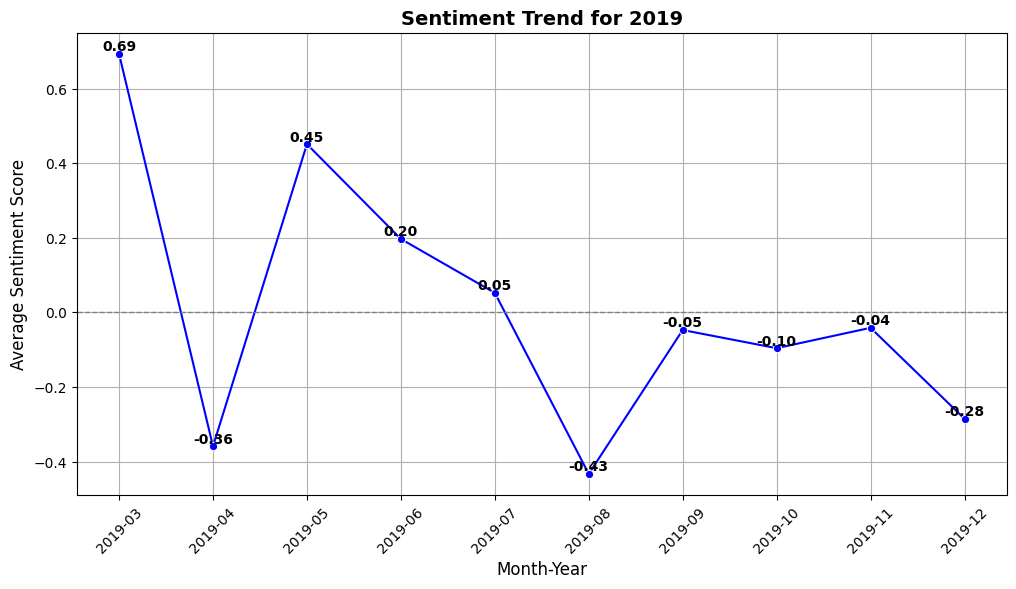

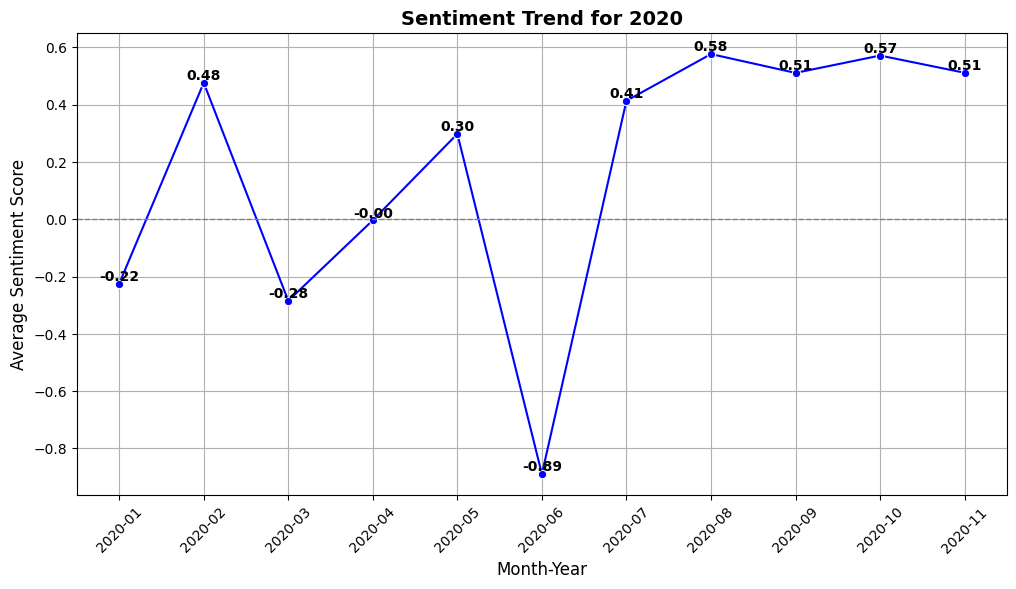

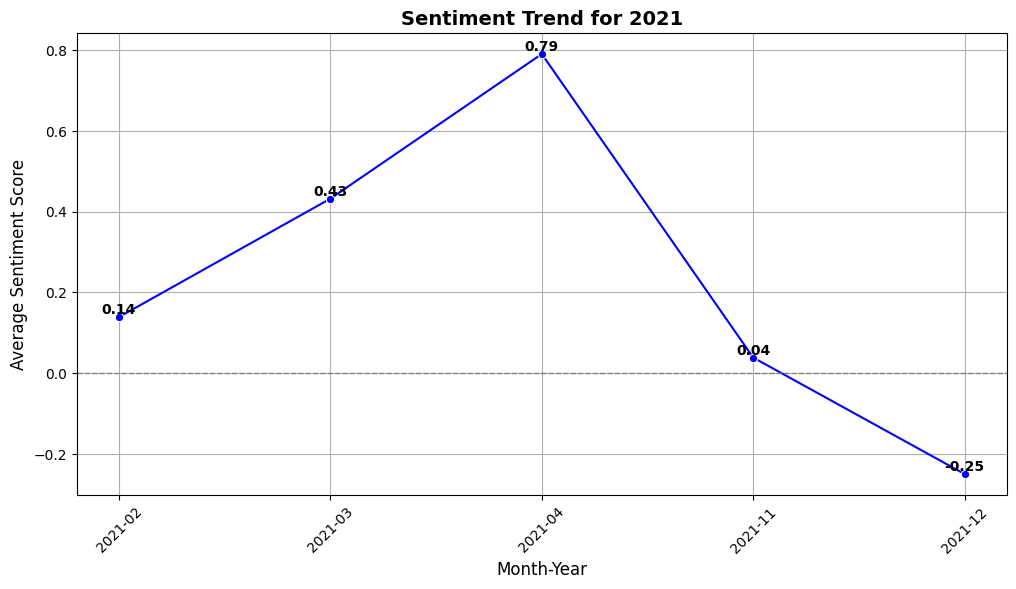

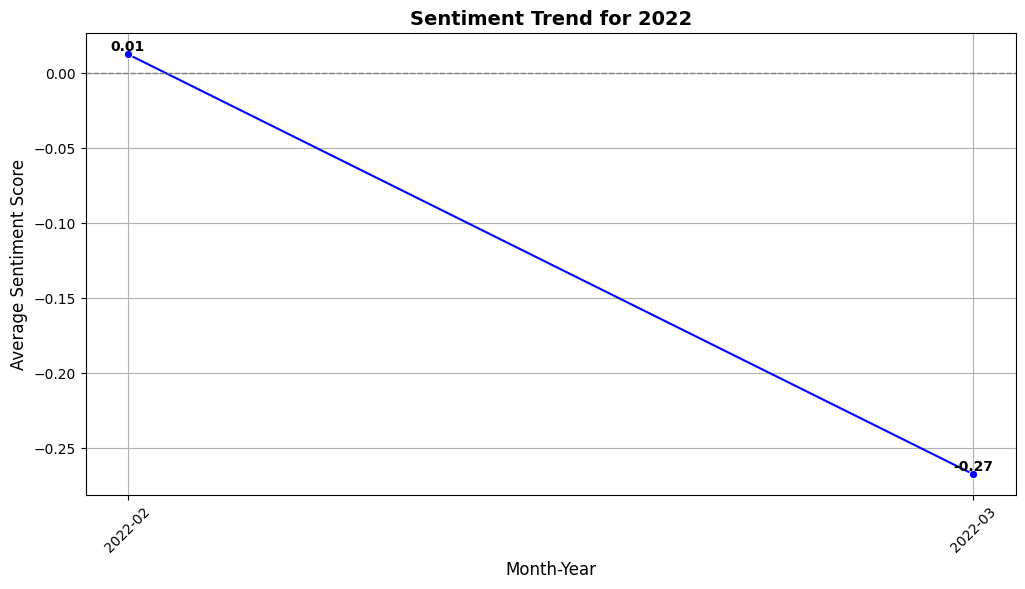

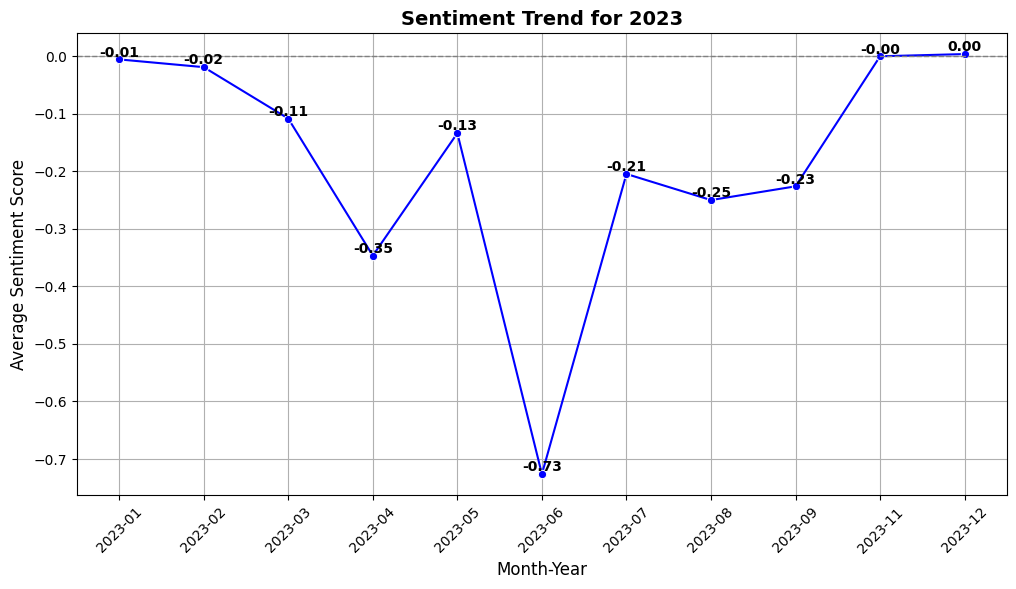

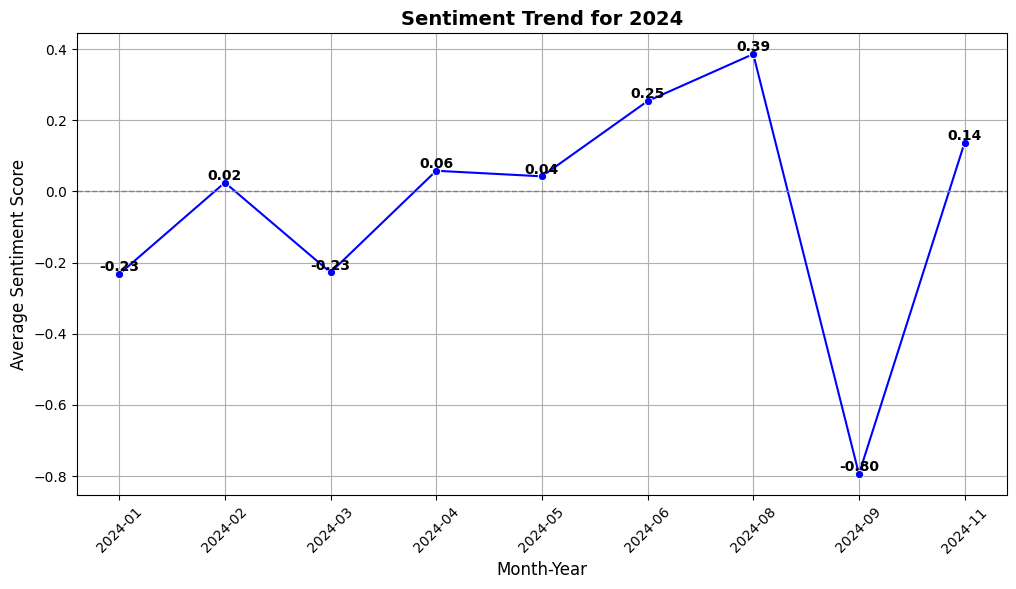

In [ ]:
!pip install vaderSentiment
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load the dataset
df = pd.read_csv("/content/GWR with date.csv")

# Convert 'date_of_experience' column to datetime format
df['date_of_experience'] = pd.to_datetime(df['date_of_experience'], errors='coerce')

# Drop any rows where date conversion failed
df = df.dropna(subset=['date_of_experience'])

# Extract year and month for filtering later
df['year'] = df['date_of_experience'].dt.year
df['month'] = df['date_of_experience'].dt.month

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return 0  # Neutral if no text
    return analyzer.polarity_scores(text)['compound']

# Apply sentiment analysis on 'content' column
df['sentiment_score'] = df['content'].apply(get_sentiment)

# Aggregate sentiment scores over time (monthly)
df['month_year'] = df['date_of_experience'].dt.to_period('M')  # Group by Month-Year
sentiment_trend = df.groupby(['year', 'month_year'])['sentiment_score'].mean().reset_index()

# Convert period to string for plotting
sentiment_trend['month_year'] = sentiment_trend['month_year'].astype(str)

# Display sentiment trend table
print("\nSentiment Trend Table (Month-Year Wise):")
print(sentiment_trend[['year', 'month_year', 'sentiment_score']].to_string(index=False))

# Function to plot sentiment trends with labels
def plot_sentiment_trend(data, title):
    plt.figure(figsize=(12, 6))
    ax = sns.lineplot(data=data, x='month_year', y='sentiment_score', marker='o', color='b')

    # Add labels to each point
    for i, row in data.iterrows():
        plt.text(row['month_year'], row['sentiment_score'], f"{row['sentiment_score']:.2f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

    plt.xticks(rotation=45)
    plt.axhline(0, color='gray', linestyle='dashed', linewidth=1)  # Neutral sentiment line
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Month-Year", fontsize=12)
    plt.ylabel("Average Sentiment Score", fontsize=12)
    plt.grid(True)
    plt.show()

# Plot overall sentiment trend
plot_sentiment_trend(sentiment_trend, "Overall Sentiment Trend (2019-2024)")

# Generate separate plots for each year
years = [2019, 2020, 2021, 2022, 2023, 2024]

for year in years:
    df_year = sentiment_trend[sentiment_trend['year'] == year]

    # Plot for the specific year with labels
    plot_sentiment_trend(df_year, f"Sentiment Trend for {year}")


In [ ]:
file_path = "/content/GWR with date.csv"  # Replace with your actual CSV file path
df = pd.read_csv(file_path)
df.head(10)

,username,rating,title,content,date_of_experience
0,Yuriy Bezgin,1,Why would you cancel trains at peak time each ...,Price is high. Bookings doesn't work. Trains a...,No Date
1,RU,1,GwR should not be allowed to run any train route,"Book a train, reserve a sit just to then spend...",No Date
2,EY,1,Officious and bumptuous 'Julie' of…,Officious and bumptuous 'Julie' of Great Weste...,No Date
3,EA,1,Utterly dishonest,Utterly dishonest. I booked a service that did...,No Date
4,AA,1,GWR delay repay and refund portal site…,GWR delay repay and refund portal site has to ...,No Date
5,Chris Turner,1,Most uncomfortable seats ever!,It's like they have gone out of their way to m...,No Date
6,JW,5,Having to travel to Paddington from…,Having to travel to Paddington from Cardiff ce...,No Date
7,EM,1,Terrible company that doesn't give a damn abou...,Why aren't you providing the service that you ...,No Date
8,LL,1,Carriages reduced from 9 to 5,"Carriages reduced from 9 to 5. Overcrowded, pa...",No Date
9,Faye Cole,1,Awful customer service,Awful customer service and I use the train a l...,No Date


**Naive Bayes classification**


**Feature Engineering**

Try TF-IDF or word embeddings instead of simple bag-of-words to improve word representation.

Include n-grams (bigrams, trigrams) to capture contextual meaning

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


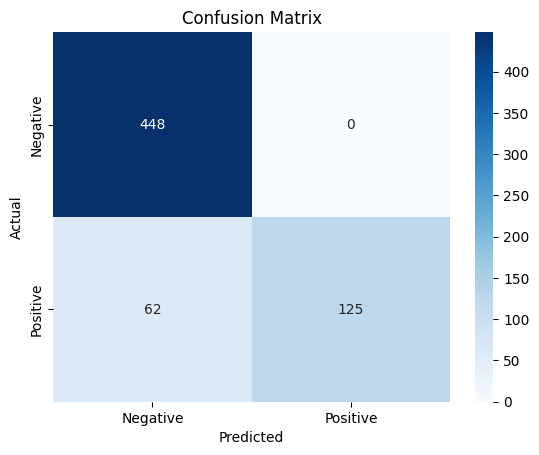


Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      1.00      0.94       448
    Positive       1.00      0.67      0.80       187

    accuracy                           0.90       635
   macro avg       0.94      0.83      0.87       635
weighted avg       0.91      0.90      0.90       635



In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Download NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")

# Load the dataset
df = pd.read_csv("/content/GWR with date.csv")

# Drop missing values in 'content' and 'rating'
df = df.dropna(subset=['content', 'rating'])

# Map ratings to sentiment categories
def map_sentiment(rating):
    if rating >= 3:
        return "Positive"
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(map_sentiment)

# Text Cleaning Function
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\W+', ' ', text)  # Remove special characters
    words = text.split()
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words]  # Lemmatization
    return " ".join(words)

# Apply text cleaning
df["cleaned_content"] = df["content"].apply(clean_text)

# Define features and labels
X = df["cleaned_content"]
y = df["sentiment"]

# Convert labels to numerical format
# Updated label_mapping to only include 'Negative' and 'Positive'
label_mapping = {"Negative": 0, "Positive": 1}
y = y.map(label_mapping)

# TF-IDF vectorization with bigrams & trigrams
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)  # Limit features to avoid overfitting
X_tfidf = vectorizer.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.3, random_state=42, stratify=y)

# Compute class weights to balance the dataset
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# Train Naïve Bayes Model
model = MultinomialNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
# Updated heatmap to use label_mapping.keys() for labels
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_mapping.keys(), yticklabels=label_mapping.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
# Updated classification_report to use label_mapping.keys() for target_names
print(classification_report(y_test, y_pred, target_names=label_mapping.keys()))

**Logistic Classification Model**

**Python Implementation for Logistic Regression with Gradient Descent**

The goal is to analyze how the logistic regression model performs as it learns from the data, adjusting its parameters (𝜃) to minimize the cost function.

By minimizing the cost function using gradient descent, the model's performance improves, allowing it to classify customer sentiment (Positive/Negative) more accurately based on review content.

This process also helps in understanding which features (e.g., specific words or n-grams) have the most influence on the sentiment classification, aiding in the sensitivity analysis.



Removing phone numbers, irrelevant symbols for improved text processing

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


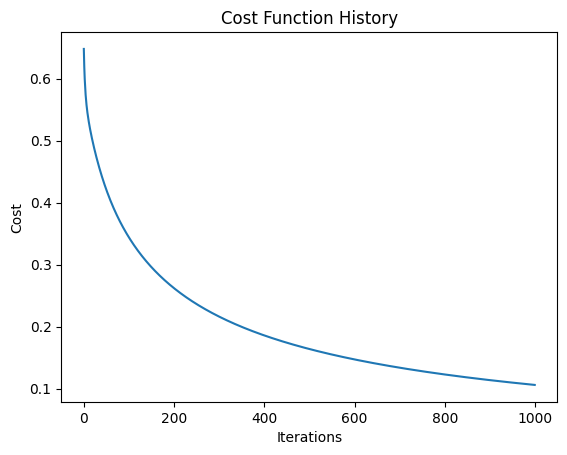

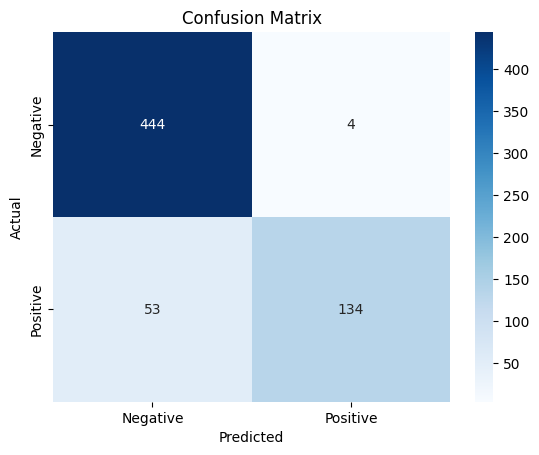


Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.99      0.94       448
    Positive       0.97      0.72      0.82       187

    accuracy                           0.91       635
   macro avg       0.93      0.85      0.88       635
weighted avg       0.92      0.91      0.91       635



In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report

# Download stopwords if not already present
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Load the dataset
df = pd.read_csv("/content/GWR with date.csv")

# Ensure no missing values in 'content' and 'rating'
df = df.dropna(subset=["content", "rating"])

# Map ratings to sentiment categories (3 and above is Positive, below 3 is Negative)
df["sentiment"] = df["rating"].apply(lambda x: 1 if x >= 3 else 0)

# Function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d{10,}', '', text)  # Remove phone numbers (10+ digits)
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = ' '.join([word for word in text.split() if word not in stop_words])  # Remove stopwords
    return text

# Apply text cleaning
df["cleaned_content"] = df["content"].apply(clean_text)

# Convert text to features using bag-of-words (unigrams & bigrams)
vectorizer = CountVectorizer(ngram_range=(1, 2))
X = vectorizer.fit_transform(df["cleaned_content"]).toarray()
y = df["sentiment"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Logistic Regression Cost Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, theta):
    m = len(y)
    predictions = sigmoid(np.dot(X, theta))
    cost = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost

# Gradient Descent
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    cost_history = []

    for i in range(num_iters):
        predictions = sigmoid(np.dot(X, theta))
        gradient = (1/m) * np.dot(X.T, predictions - y)
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# Add intercept term to X (a column of ones)
X_train_with_intercept = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_with_intercept = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Initialize theta
initial_theta = np.zeros(X_train_with_intercept.shape[1])

# Set learning rate and number of iterations
alpha = 0.1
num_iters = 1000

# Run gradient descent
theta, cost_history = gradient_descent(X_train_with_intercept, y_train, initial_theta, alpha, num_iters)

# Plot cost function history
plt.plot(range(num_iters), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function History")
plt.show()

# Make predictions
y_pred_prob = sigmoid(np.dot(X_test_with_intercept, theta))
y_pred = [1 if prob >= 0.6 else 0 for prob in y_pred_prob]

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))


In [ ]:
import numpy as np
import pandas as pd

# After running gradient descent and obtaining theta values
# Get the feature names (words/n-grams)
words = vectorizer.get_feature_names_out()

# Sort the theta values (in absolute terms) to identify the most influential words
theta_sorted_idx = np.argsort(np.abs(theta))[::-1]  # Sorting by absolute theta values in descending order

# Get the most influential words and their corresponding theta values
top_n = 10  # Number of top words to display
top_words = [(words[idx], theta[idx]) for idx in theta_sorted_idx[:top_n]]

# Display the most influential words with their corresponding theta values
print("Most influential words and their theta values:")
for word, value in top_words:
    print(f"Word: {word}, Theta: {value}")

Most influential words and their theta values:
Word: thank abdul, Theta: 1.1275374601241117
Word: helpful absolute, Theta: 1.060290457232062
Word: whatsapp account, Theta: 0.8518065702858234
Word: great absolutely, Theta: 0.7062508333878371
Word: brad answered, Theta: 0.6633624929269537
Word: bike adventure, Theta: 0.6142543537078751
Word: thanks absolutely, Theta: 0.5993760778740826
Word: dont access, Theta: -0.58668458725787
Word: excellent assisting, Theta: 0.582497310456905
Word: friendly accurate, Theta: 0.5808382580735229


Gradient Descent: Learning rate Alpha

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


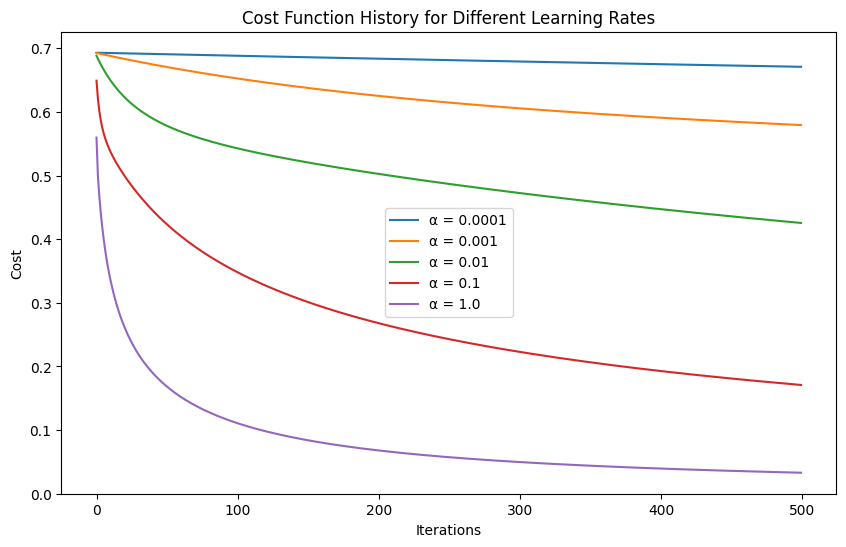

In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, classification_report

# Download stopwords if not already present
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Load the dataset
df = pd.read_csv("/content/GWR with date.csv")

# Ensure no missing values in 'content' and 'rating'
df = df.dropna(subset=["content", "rating"])

# Map ratings to sentiment categories (3 and above is Positive, below 3 is Negative)
df["sentiment"] = df["rating"].apply(lambda x: 1 if x >= 3 else 0)

# Function to clean text
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d{10,}', '', text)  # Remove phone numbers (10+ digits)
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'http\S+|www\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = ' '.join([word for word in text.split() if word not in stop_words])  # Remove stopwords
    return text

# Apply text cleaning
df["cleaned_content"] = df["content"].apply(clean_text)

# Convert text to features using bag-of-words (unigrams & bigrams)
vectorizer = CountVectorizer(ngram_range=(1, 2))
X = vectorizer.fit_transform(df["cleaned_content"]).toarray()
y = df["sentiment"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression Cost Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, theta):
    m = len(y)
    predictions = sigmoid(np.dot(X, theta))
    cost = -(1/m) * np.sum(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return cost

# Gradient Descent
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    cost_history = []

    for i in range(num_iters):
        predictions = sigmoid(np.dot(X, theta))
        gradient = (1/m) * np.dot(X.T, predictions - y)
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))

    return theta, cost_history

# Add intercept term to X (a column of ones)
X_train_with_intercept = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_with_intercept = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Initialize theta
initial_theta = np.zeros(X_train_with_intercept.shape[1])

# Different learning rates to test
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0]
num_iters = 500

# Run gradient descent for different alpha values
plt.figure(figsize=(10, 6))
for alpha in alphas:
    theta = np.zeros(X_train_with_intercept.shape[1])  # Reset theta for each alpha
    _, cost_history = gradient_descent(X_train_with_intercept, y_train, theta, alpha, num_iters)
    plt.plot(range(num_iters), cost_history, label=f'α = {alpha}')

# Plot cost function history for different learning rates
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function History for Different Learning Rates")
plt.legend()
plt.show()


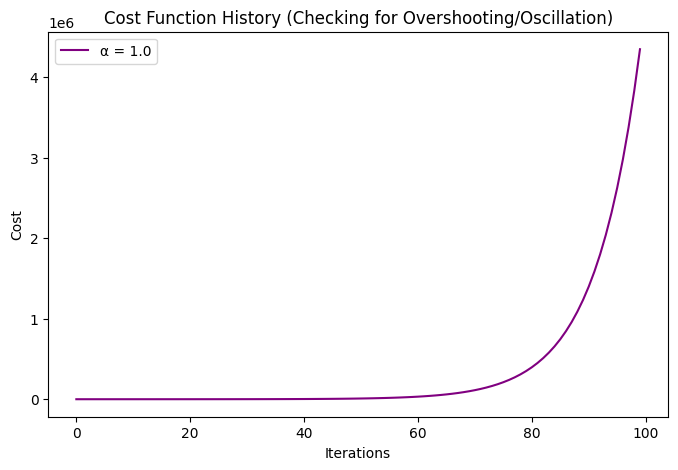

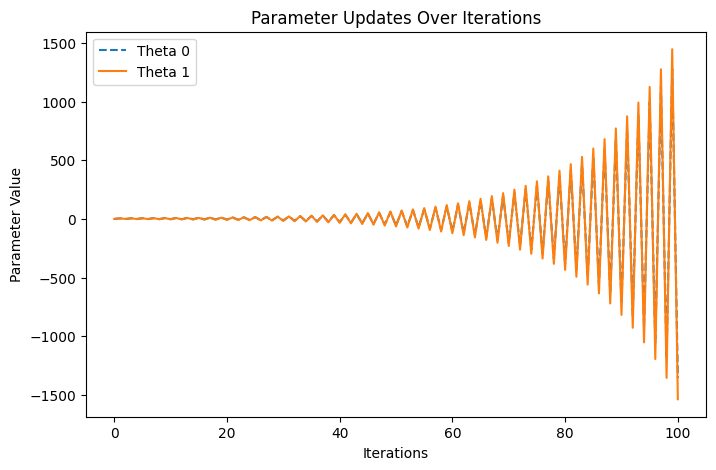

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated Cost Function (Logistic Regression or Linear Regression)
def compute_cost(theta, X, y):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

# Gradient Descent Function
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    theta_history = [theta.copy()]

    for i in range(iterations):
        gradients = (1 / m) * X.T.dot(X.dot(theta) - y)
        theta -= alpha * gradients  # Parameter update
        cost = compute_cost(theta, X, y)  # Compute cost
        cost_history.append(cost)
        theta_history.append(theta.copy())

    return theta, cost_history, theta_history

# Generate Synthetic Data (Linear Regression Example)
np.random.seed(42)
m = 100  # Number of samples
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)  # True relation: y = 4 + 3x + noise
X_b = np.c_[np.ones((m, 1)), X]  # Add bias term

# Initialize parameters
theta_init = np.random.randn(2, 1)

# Run gradient descent for alpha = 1.0
alpha = 1.0
iterations = 100
theta_final, cost_history, theta_history = gradient_descent(X_b, y, theta_init, alpha, iterations)

# Plot cost function to check for oscillations
plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history, label=f"α = {alpha}", color="purple")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function History (Checking for Overshooting/Oscillation)")
plt.legend()
plt.show()

# Plot parameter updates to check for instability
theta_0_vals = [t[0, 0] for t in theta_history]
theta_1_vals = [t[1, 0] for t in theta_history]

plt.figure(figsize=(8, 5))
plt.plot(range(iterations+1), theta_0_vals, label="Theta 0", linestyle="dashed")
plt.plot(range(iterations+1), theta_1_vals, label="Theta 1", linestyle="solid")
plt.xlabel("Iterations")
plt.ylabel("Parameter Value")
plt.title("Parameter Updates Over Iterations")
plt.legend()
plt.show()


α=1.0 is too high for this dataset and model.
The cost function diverges, and parameters oscillate wildly, making it impossible for gradient descent to converge.
A lower learning rate (e.g., 0.1 or 0.01) should be tested to ensure stable and smooth convergence.

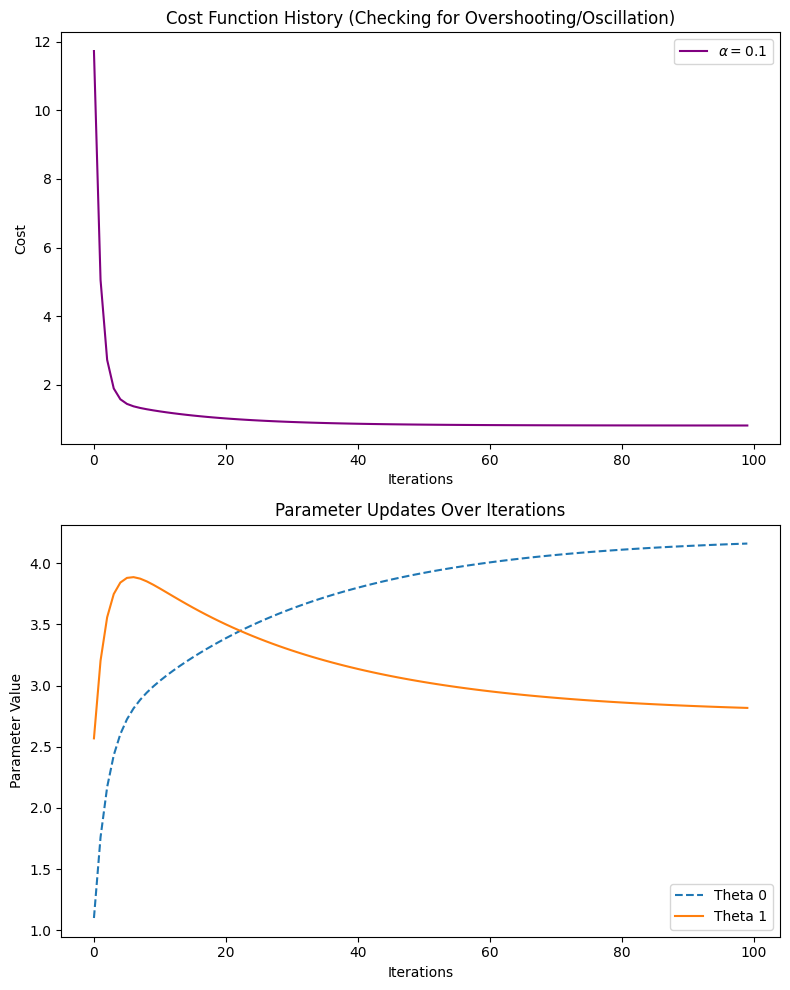

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data (simple linear regression example)
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Adding bias term (X0 = 1 for all samples)
X_b = np.c_[np.ones((100, 1)), X]

# Gradient Descent Parameters
alpha = 0.1  # Learning rate (now testing for α = 0.1)
iterations = 100
m = len(y)  # Number of training examples

# Initialize theta (parameters)
theta = np.random.randn(2, 1)
cost_history = []
theta_history = []

# Gradient Descent Algorithm
for i in range(iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta -= alpha * gradients
    cost = (1/m) * np.sum((X_b.dot(theta) - y) ** 2)

    cost_history.append(cost)
    theta_history.append(theta.copy())

# Convert theta_history to numpy array for plotting
theta_history = np.array(theta_history)

# Plot Cost Function History
plt.figure(figsize=(8, 10))

plt.subplot(2, 1, 1)
plt.plot(range(iterations), cost_history, color='purple', label=r"$\alpha = 0.1$")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function History (Checking for Overshooting/Oscillation)")
plt.legend()

# Plot Parameter Updates
plt.subplot(2, 1, 2)
plt.plot(range(iterations), theta_history[:, 0], linestyle="dashed", label="Theta 0")
plt.plot(range(iterations), theta_history[:, 1], label="Theta 1")
plt.xlabel("Iterations")
plt.ylabel("Parameter Value")
plt.title("Parameter Updates Over Iterations")
plt.legend()

plt.tight_layout()
plt.show()



α = 0.1 is a good choice because it balances fast convergence with stability.
There is no oscillation or divergence, meaning the model is learning efficiently.
The parameters are adjusting properly without extreme fluctuations, leading to a stable solution

** Topic Modeling (LDA)**


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



🔍 Coherence Score by Number of Topics:

Topics: 3 ➜ Coherence Score: 0.4135
Topics: 4 ➜ Coherence Score: 0.3644
Topics: 5 ➜ Coherence Score: 0.3741
Topics: 6 ➜ Coherence Score: 0.3748
Topics: 7 ➜ Coherence Score: 0.4125


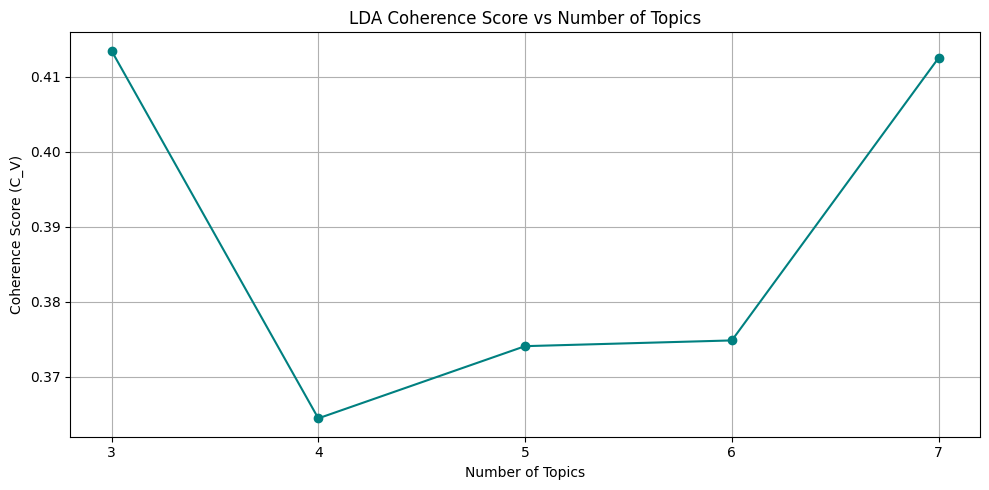

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import gensim
import gensim.corpora as corpora
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Phrases, LdaModel, TfidfModel
from gensim.models.phrases import Phraser
from gensim.models import CoherenceModel
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load data
df = pd.read_csv("/content/GWR with date.csv")
df['content'] = df['content'].fillna('').astype(str)

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Add domain-specific and vague stopwords
custom_stopwords = {
    "gwr", "trains", "train", "services", "get", "would", "even", "one", "told", "say",
    "got", "still", "back", "time", "people", "day", "week", "month", "customer",
    "really", "problem", "also", "much", "need", "use"
}
stop_words.update(custom_stopwords)

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

# Tokenization
def tokenize(text):
    text = clean_text(text)
    tokens = text.split()
    return [word for word in tokens if word not in stop_words and len(word) > 2]

df['tokens'] = df['content'].apply(tokenize)

# Bigrams and Trigrams
bigram = Phrases(df['tokens'], min_count=5, threshold=10)
trigram = Phrases(bigram[df['tokens']], threshold=10)
bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

# Final processing: lemmatization + filtering
def process_tokens(tokens):
    tokens = bigram_mod[tokens]
    tokens = trigram_mod[tokens]
    return [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

df['processed_tokens'] = df['tokens'].apply(process_tokens)
df = df[df['processed_tokens'].map(len) > 0].reset_index(drop=True)

# Build dictionary and corpus
dictionary = corpora.Dictionary(df['processed_tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.6)
corpus = [dictionary.doc2bow(text) for text in df['processed_tokens']]
tfidf_model = TfidfModel(corpus)
corpus_tfidf = tfidf_model[corpus]

# Loop through different topic numbers and compute coherence
topic_range = range(3, 8)
coherence_scores = []

print("\n🔍 Coherence Score by Number of Topics:\n")
for num_topics in topic_range:
    lda_model = LdaModel(
        corpus=corpus_tfidf,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=20,
        iterations=200
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df['processed_tokens'],
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f"Topics: {num_topics} ➜ Coherence Score: {score:.4f}")

# Plot coherence score vs number of topics
plt.figure(figsize=(10, 5))
plt.plot(topic_range, coherence_scores, marker='o', linestyle='-', color='teal')
plt.title("LDA Coherence Score vs Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (C_V)")
plt.grid(True)
plt.xticks(topic_range)
plt.tight_layout()
plt.show()





[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



🔍 Top words per topic:

Topic #1: september utterly high shocking service using bother seem reservation seat
Topic #2: website refund ticket app worst perfect number page assistant week
Topic #3: train time ticket journey seat service people minute delay hour


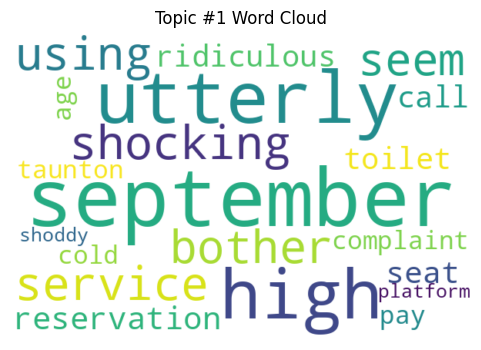

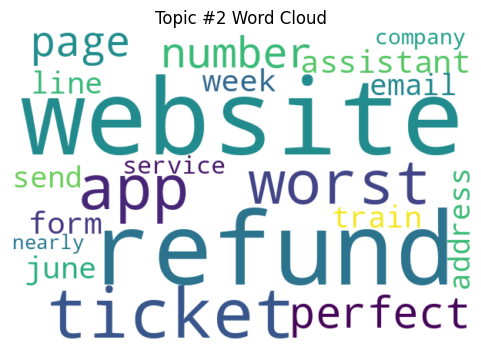

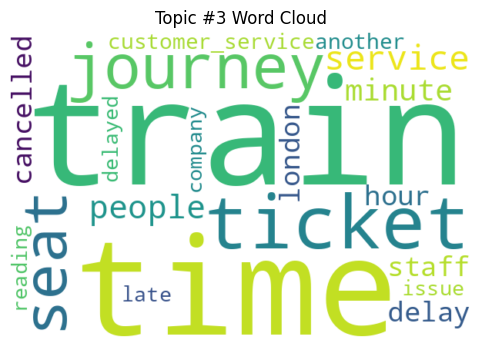


✅ LDA Coherence Score (C_V): 0.4224
684     [frustrating, refund, experiencei, emailed, tr...
834     [three, hour, paddington, maidenhead, way, hom...
629     [worst, trainline, taken, multiple, journey, e...
241     [bought_ticket, online, travel, next_day, forc...
1143    [weeks_ago, cancel, journey, son, family, goin...
Name: processed_tokens, dtype: object


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import gensim
import gensim.corpora as corpora
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Phrases, LdaModel, TfidfModel
from gensim.models.phrases import Phraser
from gensim.models import CoherenceModel
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load dataset
df = pd.read_csv("/content/GWR with date.csv")
df['content'] = df['content'].fillna('').astype(str)

# Define stopwords and add custom ones
stop_words = set(stopwords.words('english'))
custom_stopwords = {
    "gwr", "trains", "services", "get", "would", "even", "one", "told", "say",
    "got", "still", "back", "week", "month",
    "really", "also", "much", "need", "use","date_experience","getting","put","took","gave","half","extremely","well","that's","could","given"
}
stop_words.update(custom_stopwords)

# Lemmatizer
lemmatizer = WordNetLemmatizer()

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # Remove special characters
    return text

# Tokenizer
def tokenize(text):
    text = clean_text(text)
    tokens = text.split()
    return [word for word in tokens if word not in stop_words and len(word) > 2]

# Apply tokenization
df['tokens'] = df['content'].apply(tokenize)

# Build bigram and trigram models
bigram = Phrases(df['tokens'], min_count=5, threshold=10)
trigram = Phrases(bigram[df['tokens']], threshold=10)
bigram_mod = Phraser(bigram)
trigram_mod = Phraser(trigram)

# Lemmatize + stopword filter
def process_tokens(tokens):
    tokens = bigram_mod[tokens]
    tokens = trigram_mod[tokens]
    return [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

# Apply token processing
df['processed_tokens'] = df['tokens'].apply(process_tokens)

# Filter out empty processed rows
df = df[df['processed_tokens'].map(len) > 0].reset_index(drop=True)

# Create dictionary and corpus
dictionary = corpora.Dictionary(df['processed_tokens'])
dictionary.filter_extremes(no_below=5, no_above=0.6)
corpus = [dictionary.doc2bow(tokens) for tokens in df['processed_tokens']]

# TF-IDF model
tfidf_model = TfidfModel(corpus)
corpus_tfidf = tfidf_model[corpus]

# Train LDA Model with 3 Topics (based on coherence tuning)
lda_model = LdaModel(
    corpus=corpus_tfidf,
    id2word=dictionary,
    num_topics=3,
    random_state=42,
    passes=20,
    iterations=200
)

# Display top words per topic
print("\n🔍 Top words per topic:\n")
for i, topic in lda_model.show_topics(num_topics=3, num_words=10, formatted=False):
    top_words = [word for word, _ in topic]
    print(f"Topic #{i+1}: {' '.join(top_words)}")

# Plot word clouds
def plot_topic_wordcloud(lda_model, topic_id, num_words=20):
    words_probs = lda_model.show_topic(topic_id, topn=num_words)
    freqs = {word: prob for word, prob in words_probs}
    wc = WordCloud(width=600, height=400, background_color='white')
    wc.generate_from_frequencies(freqs)

    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Topic #{topic_id+1} Word Cloud")
    plt.show()

# Generate word clouds for each topic
for topic_id in range(3):
    plot_topic_wordcloud(lda_model, topic_id)

# Calculate Coherence Score
coherence_model = CoherenceModel(
    model=lda_model,
    texts=df['processed_tokens'],
    dictionary=dictionary,
    coherence='c_v'
)
coherence_score = coherence_model.get_coherence()
print(f"\n LDA Coherence Score (C_V): {coherence_score:.4f}")
print(df['processed_tokens'].sample(5))

**Visualize Topic-Word Distributions - Dirchelet Simplex**

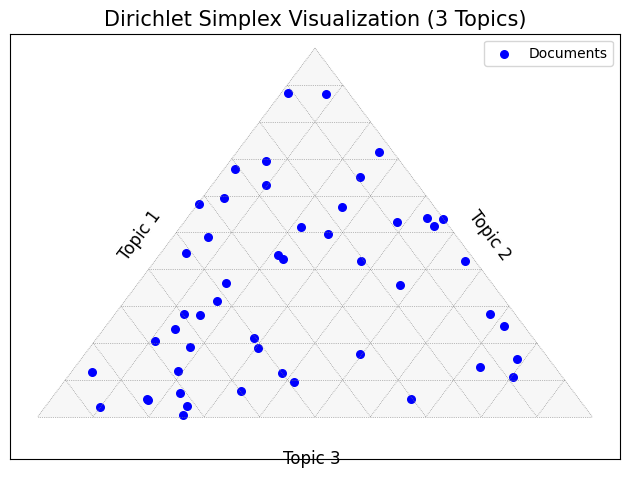

In [ ]:
# If not installed, install the package:
!pip install python-ternary

import numpy as np
import matplotlib.pyplot as plt
import ternary

# For demonstration, assume we have 3 topics.
# We generate a synthetic document-topic distribution using the Dirichlet distribution.
# In your case, replace this with your actual document-topic distributions from LDA.
np.random.seed(42)
num_docs = 50
doc_topic_distributions = np.random.dirichlet(alpha=[1, 1, 1], size=num_docs)

# Create a ternary plot with scale=1 (each document's topic probabilities sum to 1)
figure, tax = ternary.figure(scale=1.0)
tax.set_title("Dirichlet Simplex Visualization (3 Topics)", fontsize=15)

# Plot each document as a point in the ternary space.
points = doc_topic_distributions.tolist()
tax.scatter(points, marker='o', color='blue', label="Documents", s=30)

# Set custom corner labels using axis label functions.
tax.left_axis_label("Topic 1", fontsize=12)
tax.right_axis_label("Topic 2", fontsize=12)
tax.bottom_axis_label("Topic 3", fontsize=12)

# Additional formatting for clarity
tax.legend()
tax.gridlines(multiple=0.1, color="grey")
tax.clear_matplotlib_ticks()

plt.tight_layout()
plt.show()






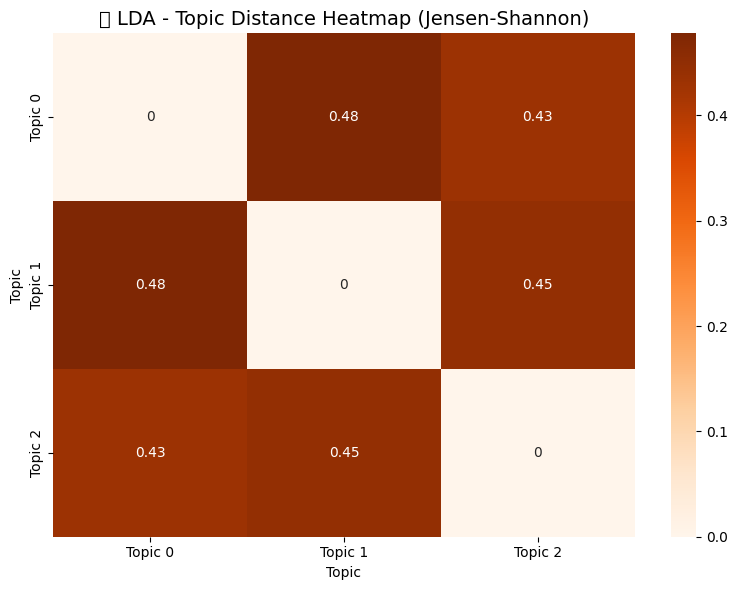

In [ ]:
from scipy.spatial.distance import jensenshannon
from itertools import combinations

# Get topic-word distributions
num_topics = lda_model.num_topics
topic_term_matrix = lda_model.get_topics()  # shape: [n_topics, n_terms]

# Compute pairwise Jensen-Shannon divergence
distance_matrix = np.zeros((num_topics, num_topics))

for i in range(num_topics):
    for j in range(num_topics):
        if i != j:
            distance = jensenshannon(topic_term_matrix[i], topic_term_matrix[j])
            distance_matrix[i, j] = distance

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(distance_matrix, cmap="Oranges", annot=True,
            xticklabels=[f"Topic {i}" for i in range(num_topics)],
            yticklabels=[f"Topic {i}" for i in range(num_topics)])
plt.title("📐 LDA - Topic Distance Heatmap (Jensen-Shannon)", fontsize=14)
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


**BERTopic Model**

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Load dataset
df = pd.read_csv("/content/GWR with date.csv")
df['content'] = df['content'].fillna('').astype(str)

# NLTK stopwords + custom domain stopwords
stop_words = set(stopwords.words('english'))
custom_stopwords = {
    "gwr", "train", "trains", "service", "ticket", "get", "one", "still",
    "brad", "whatsapp", "viawhatsapp", "date", "experience", "date experience",
    "august", "september", "october", "june", "january", "quick", "bike space"
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

# Clean and preprocess text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)             # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text)                # Remove numbers and punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    text = clean_text(text)
    tokens = text.split()
    cleaned = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words and len(token) > 2
    ]
    return " ".join(cleaned)

# Apply preprocessing
df["cleaned_text"] = df["content"].apply(preprocess)
df = df[df["cleaned_text"].str.strip() != ""]

# Set up BERTopic with CountVectorizer
vectorizer_model = CountVectorizer(ngram_range=(1, 3), stop_words="english")
topic_model = BERTopic(vectorizer_model=vectorizer_model, language="english", top_n_words=10)

# Fit the model
topics, probs = topic_model.fit_transform(df["cleaned_text"])

# Show top 3 topics
from itertools import islice
valid_topics = topic_model.get_topic_info().Topic.unique().tolist()
valid_topics = [t for t in valid_topics if t != -1]

print("\nTop 3 Topics:")
for topic_id in islice(valid_topics, 3):
    print(f"\nTopic #{topic_id}:")
    print(topic_model.get_topic(topic_id))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



Top 3 Topics:

Topic #0:
[('time', 0.01709561758008536), ('seat', 0.013113053466339699), ('journey', 0.01310118201194253), ('staff', 0.0128772488848382), ('customer', 0.011842217174851863), ('ticket', 0.010360266989030044), ('refund', 0.010160125656645596), ('day', 0.00973232534188701), ('people', 0.00953700120299397), ('paddington', 0.009463894204845811)]

Topic #1:
[('bike', 0.1354672006090896), ('space', 0.06121495841611571), ('reservation', 0.05138224497465285), ('bike space', 0.047184956501514934), ('booking', 0.04692369663934085), ('helpful', 0.035713707840203085), ('book', 0.03563433950517628), ('bike reservation', 0.03406744011301905), ('book bike', 0.0303035919002749), ('booking bike', 0.029263848414833725)]

Topic #2:
[('helpful', 0.06504380606645682), ('customer', 0.04692925439723543), ('twitter', 0.046334231940701555), ('thank', 0.035517299248894754), ('michaela', 0.03427000311630537), ('help', 0.03266523889142357), ('thanks', 0.0313598887500457), ('great', 0.0281143288407

In [ ]:
from gensim.models import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer

# Extract topics as lists of words (excluding outlier topic -1)
topics = topic_model.get_topics()
topic_words = [ [word for word, _ in topic_model.get_topic(topic)]
                for topic in topic_model.get_topic_info().Topic.unique() if topic != -1 ]

# Use preprocessed tokens used in BERTopic
texts = df["cleaned_text"].apply(lambda x: x.split()).tolist()

# Create a dictionary and corpus for coherence
from gensim.corpora.dictionary import Dictionary
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# Calculate coherence score
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'  # you can also try 'u_mass', 'c_uci', etc.
)
coherence_score = coherence_model.get_coherence()

print(f" BERTopic Coherence Score (c_v): {coherence_score:.4f}")


🔍 BERTopic Coherence Score (c_v): 0.4700


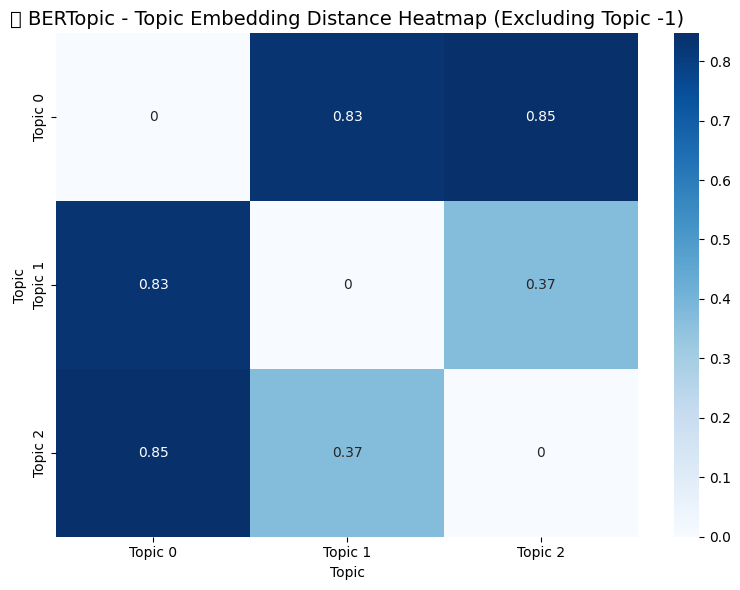

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_distances

# Step 1: Filter out Topic -1 from BERTopic
valid_topic_ids = [i for i in topic_model.get_topics().keys() if i != -1]

# Step 2: Get only embeddings for valid topics
topic_embeddings = topic_model.topic_embeddings_
filtered_embeddings = np.array([topic_embeddings[i] for i in valid_topic_ids])

# Step 3: Compute cosine distance between valid topics
distance_matrix = cosine_distances(filtered_embeddings)

# Step 4: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(distance_matrix, cmap='Blues', annot=True,
            xticklabels=[f"Topic {i}" for i in valid_topic_ids],
            yticklabels=[f"Topic {i}" for i in valid_topic_ids])
plt.title("📐 BERTopic - Topic Embedding Distance Heatmap (Excluding Topic -1)", fontsize=14)
plt.xlabel("Topic")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()


